# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset. 

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [2]:
# Load amounts from CSV for use in Q1
_df_temp = pd.read_csv("transactions.csv")
amounts = _df_temp["amount"].tolist()

def summarise(amounts, threshold):
    """Return a dict summarising the amounts list relative to a threshold."""
    above_threshold = sorted([a for a in amounts if a > threshold], reverse=True)
    mean = sum(amounts) / len(amounts)
    count_above = len(above_threshold)
    return {
        "above_threshold": above_threshold,
        "mean": mean,
        "count_above": count_above,
    }

result = summarise(amounts, threshold=500)
print("=== Q1 Result ===")
print(f"Mean: {result['mean']:.2f}")
print(f"Count above 500: {result['count_above']}")
print(f"First 10 above threshold (sorted desc): {result['above_threshold'][:10]}")
print(f"Total above threshold: {len(result['above_threshold'])}")

=== Q1 Result ===
Mean: 1253.02
Count above 500: 2392
First 10 above threshold (sorted desc): [14205.88, 14011.64, 13184.18, 13086.34, 12304.94, 12250.73, 12199.01, 11818.92, 11772.79, 11662.54]
Total above threshold: 2392


---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [3]:
# Load only the amount column into a NumPy array
amounts_arr = np.loadtxt("transactions.csv", delimiter=",", skiprows=1, usecols=4)

# 1. Basic statistics
print("=== Q2.1 — Basic Statistics ===")
print(f"Mean:              {np.mean(amounts_arr):.2f}")
print(f"Median:            {np.median(amounts_arr):.2f}")
print(f"Std:               {np.std(amounts_arr):.2f}")
print(f"10th percentile:   {np.percentile(amounts_arr, 10):.2f}")
print(f"90th percentile:   {np.percentile(amounts_arr, 90):.2f}")

# 2. Outlier mask
mean_val = np.mean(amounts_arr)
std_val = np.std(amounts_arr)
outlier_mask = np.abs(amounts_arr - mean_val) > 2 * std_val
print(f"\n=== Q2.2 — Outliers ===")
print(f"Number of outliers (|x - mean| > 2*std): {np.sum(outlier_mask)}")
print(f"Outlier fraction: {np.mean(outlier_mask) * 100:.2f}%")

# 3. Min-max normalisation
amounts_norm = (amounts_arr - np.min(amounts_arr)) / (np.max(amounts_arr) - np.min(amounts_arr))
print(f"\n=== Q2.3 — Min-Max Normalisation ===")
print(f"amounts_norm min: {amounts_norm.min():.4f}, max: {amounts_norm.max():.4f}")

# 4. Histogram
counts, bin_edges = np.histogram(amounts_norm, bins=10)
print(f"\n=== Q2.4 — Histogram of amounts_norm (10 bins) ===")
print(f"Bin edges:  {np.round(bin_edges, 4)}")
print(f"Counts:     {counts}")

=== Q2.1 — Basic Statistics ===
Mean:              1253.02
Median:            433.38
Std:               1989.76
10th percentile:   88.25
90th percentile:   4024.01

=== Q2.2 — Outliers ===
Number of outliers (|x - mean| > 2*std): 353
Outlier fraction: 6.82%

=== Q2.3 — Min-Max Normalisation ===
amounts_norm min: 0.0000, max: 1.0000

=== Q2.4 — Histogram of amounts_norm (10 bins) ===
Bin edges:  [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Counts:     [4020  479  191  187  141   81   47   18    8    4]


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [4]:
# 1. Load
df = pd.read_csv("transactions.csv")

# 2. Shape, dtypes, missing
print("=== Q3.2 — Shape, Dtypes, Missing ===")
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# 3. Parse datetime, add month column
df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month
print(f"\n=== Q3.3 — datetime parsed, month column added ===")
print(df[["datetime", "month"]].head())

# 4. Statistical summary for numeric columns
print(f"\n=== Q3.4 — Statistical Summary (numeric) ===")
print(df.describe())

# 5. Unique cities and categories
print(f"\n=== Q3.5 — Unique Values ===")
print(f"Number of unique cities: {df['city'].nunique()}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"\nNumber of unique categories: {df['category'].nunique()}")
print(f"Categories: {sorted(df['category'].unique())}")

=== Q3.2 — Shape, Dtypes, Missing ===
Shape: (5176, 9)

Dtypes:
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

Missing values per column:
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64

=== Q3.3 — datetime parsed, month column added ===
             datetime  month
0 2024-01-01 03:29:50      1
1 2024-01-01 04:57:03      1
2 2024-01-01 04:57:19      1
3 2024-01-01 05:33:40      1
4 2024-01-01 06:29:07      1

=== Q3.4 — Statistical Summary (numeric) ===
             amount                       datetime     cashback        month
count   5176.000000                           5176  4918.000000  5176.000000
mean    1253.022884  2024-03-30 18:06:04.610703360    29.513211     3.455564
min       10.000000            2024-01-01 03:29:50    

---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [5]:
# 1. Approved transactions
approved = df[df["status"] == "approved"]
fraction_approved = len(approved) / len(df) * 100
print(f"=== Q4.1 — Approved Transactions ===")
print(f"Approved: {len(approved)} / {len(df)} = {fraction_approved:.2f}%")

# 2. Cashback rate and suspicious flag
df["cashback_rate"] = df["cashback"] / df["amount"]
df["suspicious"] = df["cashback_rate"] > 0.10
print(f"\n=== Q4.2 — Suspicious Transactions ===")
print(f"Number of suspicious transactions (cashback_rate > 0.10): {df['suspicious'].sum()}")
print(df[df["suspicious"]][["txn_id", "amount", "cashback", "cashback_rate"]].head())

# 3. Fill missing cashback with per-category median
df["cashback"] = df.groupby("category")["cashback"].transform(
    lambda x: x.fillna(x.median())
)
print(f"\n=== Q4.3 — Missing cashback after fill ===")
print(f"Remaining missing cashback values: {df['cashback'].isnull().sum()}")

# 4. Spend tier using pd.cut
df["spend_tier"] = pd.cut(
    df["amount"],
    bins=[0, 500, 2000, float("inf")],
    labels=["low", "mid", "high"],
    right=True,
)
print(f"\n=== Q4.4 — Spend Tier Distribution ===")
print(df["spend_tier"].value_counts().sort_index())

=== Q4.1 — Approved Transactions ===
Approved: 4605 / 5176 = 88.97%

=== Q4.2 — Suspicious Transactions ===
Number of suspicious transactions (cashback_rate > 0.10): 185
        txn_id   amount  cashback  cashback_rate
44   TXN000045   781.18    138.71       0.177565
49   TXN000050  2497.92    311.23       0.124596
101  TXN000102   563.33     77.99       0.138445
120  TXN000121  1215.40    252.23       0.207528
148  TXN000149   561.60     72.54       0.129167

=== Q4.3 — Missing cashback after fill ===
Remaining missing cashback values: 0

=== Q4.4 — Spend Tier Distribution ===
spend_tier
low     2784
mid     1519
high     873
Name: count, dtype: int64


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [6]:
# 1. Category stats
category_stats = df.groupby("category").agg(
    total_spend=("amount", "sum"),
    txn_count=("amount", "count"),
    avg_txn_size=("amount", "mean"),
    decline_rate=("status", lambda x: (x == "declined").mean()),
).sort_values("total_spend", ascending=False)

print("=== Q5.1 — Category Stats (sorted by total spend descending) ===")
print(category_stats.to_string())

# 2. Top-3 merchants by total spend within each city
merchant_spend = (
    df.groupby(["city", "merchant"])["amount"]
    .sum()
    .reset_index(name="total_spend")
)
top3_merchants = (
    merchant_spend.sort_values(["city", "total_spend"], ascending=[True, False])
    .groupby("city")
    .head(3)
    .reset_index(drop=True)
)
print(f"\n=== Q5.2 — Top-3 Merchants by Total Spend per City ===")
print(top3_merchants.to_string())

# 3. Month × Category pivot table
pivot = df.pivot_table(
    values="amount", index="month", columns="category", aggfunc="mean"
)
print(f"\n=== Q5.3 — Month × Category Pivot Table (avg amount) ===")
print(pivot.round(2).to_string())

=== Q5.1 — Category Stats (sorted by total spend descending) ===
               total_spend  txn_count  avg_txn_size  decline_rate
category                                                         
Travel          2213273.63        444   4984.850518      0.340090
Electronics     1722710.26        384   4486.224635      0.377604
Shopping        1031848.97        651   1585.021459      0.188940
Healthcare       438697.56        420   1044.518000      0.061905
Dining           371893.93        768    484.236888      0.045573
Utilities        290547.44        390    744.993436      0.046154
Groceries        195293.44        905    215.793856      0.049724
Entertainment    153913.21        527    292.055427      0.037951
Fuel              67468.01        687     98.206710      0.011645

=== Q5.2 — Top-3 Merchants by Total Spend per City ===
         city       merchant  total_spend
0   Bangalore    Apple Store     96407.84
1   Bangalore          IRCTC     89028.77
2   Bangalore       Ola Cab

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


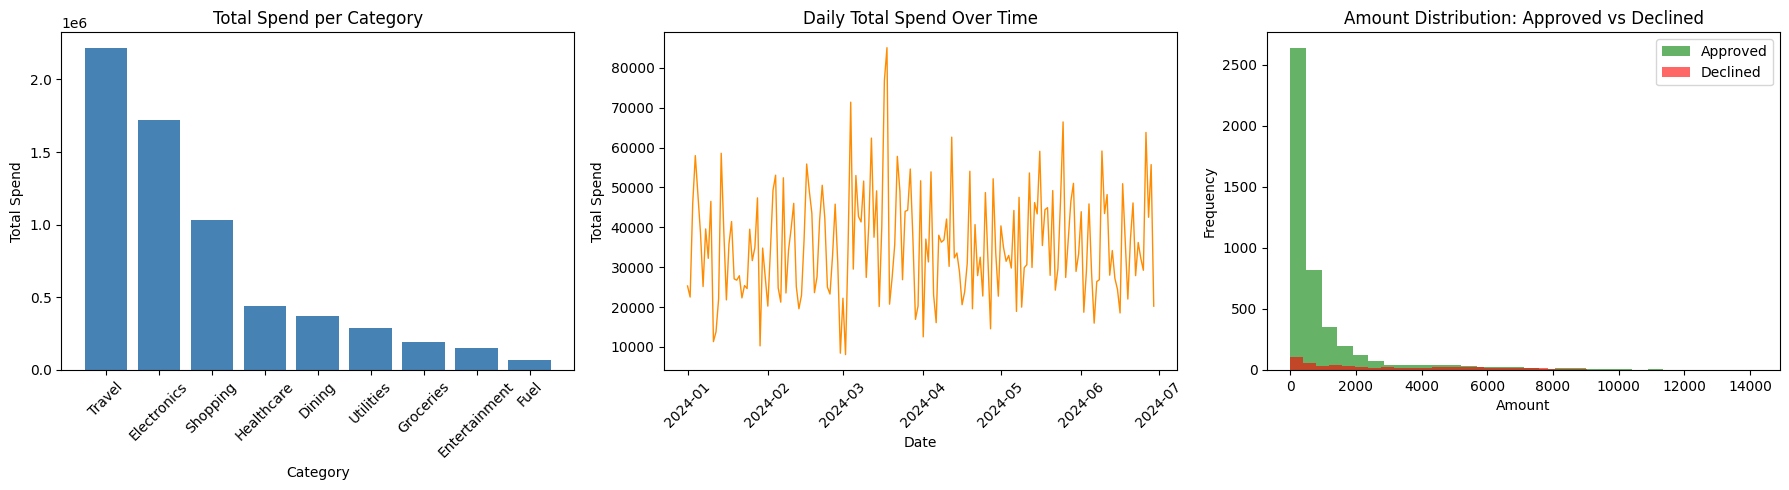

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart — Total spend per category (sorted desc)
cat_spend = df.groupby("category")["amount"].sum().sort_values(ascending=False)
axes[0].bar(cat_spend.index, cat_spend.values, color="steelblue")
axes[0].set_title("Total Spend per Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Spend")
axes[0].tick_params(axis="x", rotation=45)

# 2. Line chart — Daily total spend over time
df["date"] = df["datetime"].dt.date
daily_spend = df.groupby("date")["amount"].sum()
axes[1].plot(daily_spend.index, daily_spend.values, color="darkorange", linewidth=1)
axes[1].set_title("Daily Total Spend Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Spend")
axes[1].tick_params(axis="x", rotation=45)

# 3. Histogram — Approved vs Declined amounts overlaid
approved_amounts = df[df["status"] == "approved"]["amount"]
declined_amounts = df[df["status"] == "declined"]["amount"]
axes[2].hist(approved_amounts, bins=30, alpha=0.6, label="Approved", color="green")
axes[2].hist(declined_amounts, bins=30, alpha=0.6, label="Declined", color="red")
axes[2].set_title("Amount Distribution: Approved vs Declined")
axes[2].set_xlabel("Amount")
axes[2].set_ylabel("Frequency")
axes[2].legend()

fig.tight_layout()
plt.show()

---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.


In [8]:
def flag_velocity_fraud(df, window="1h", min_txns=3):
    """
    Flag transactions that fall inside a velocity fraud window.
    A user is in a velocity fraud event if they have >= min_txns
    transactions within any rolling window of the given size.
    
    Returns a boolean Series aligned to df.index.
    """
    fraud_flags = pd.Series(False, index=df.index)
    
    df_sorted = df.sort_values(["user_id", "datetime"])
    
    for user_id, group in df_sorted.groupby("user_id"):
        if len(group) < min_txns:
            continue
        
        group_ts = group.set_index("datetime").sort_index()
        rolling_count = group_ts["txn_id"].rolling(window, min_periods=1).count()
        
        fraud_times = rolling_count[rolling_count >= min_txns]
        
        if len(fraud_times) > 0:
            for end_time in fraud_times.index:
                start_time = end_time - pd.Timedelta(window)
                mask = (group["datetime"] > start_time) & (group["datetime"] <= end_time)
                fraud_flags.loc[group[mask].index] = True
    
    return fraud_flags


# 2. Add velocity_fraud column
df["velocity_fraud"] = flag_velocity_fraud(df, window="1h", min_txns=3)

print("=== Q7.2 — Velocity Fraud Flags ===")
print(f"Total transactions: {len(df)}")
print(f"Flagged as velocity fraud: {df['velocity_fraud'].sum()}")
print(f"Fraud fraction: {df['velocity_fraud'].mean() * 100:.2f}%")

# 3. Compare flagged vs normal
print("\n=== Q7.3 — Flagged vs Normal Comparison ===")

comparison = df.groupby("velocity_fraud").agg(
    avg_spend=("amount", "mean"),
    decline_rate=("status", lambda x: (x == "declined").mean()),
    txn_count=("txn_id", "count"),
).rename(index={True: "Flagged (Fraud)", False: "Normal"})
print(comparison.round(4).to_string())

print("\nTop categories for FLAGGED transactions:")
if df["velocity_fraud"].sum() > 0:
    flagged_cats = (
        df[df["velocity_fraud"]]
        .groupby("category")["amount"]
        .sum()
        .sort_values(ascending=False)
    )
    print(flagged_cats.to_string())
else:
    print("No flagged transactions found.")

print("\nTop categories for NORMAL transactions:")
normal_cats = (
    df[~df["velocity_fraud"]]
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)
print(normal_cats.to_string())

=== Q7.2 — Velocity Fraud Flags ===
Total transactions: 5176
Flagged as velocity fraud: 179
Fraud fraction: 3.46%

=== Q7.3 — Flagged vs Normal Comparison ===
                 avg_spend  decline_rate  txn_count
velocity_fraud                                     
Normal           1152.2990        0.0790       4997
Flagged (Fraud)  4064.8507        0.9832        179

Top categories for FLAGGED transactions:
category
Shopping         256452.64
Travel           236177.53
Electronics      233206.63
Utilities          1172.90
Entertainment       374.11
Groceries           224.47

Top categories for NORMAL transactions:
category
Travel           1977096.10
Electronics      1489503.63
Shopping          775396.33
Healthcare        438697.56
Dining            371893.93
Utilities         289374.54
Groceries         195068.97
Entertainment     153539.10
Fuel               67468.01


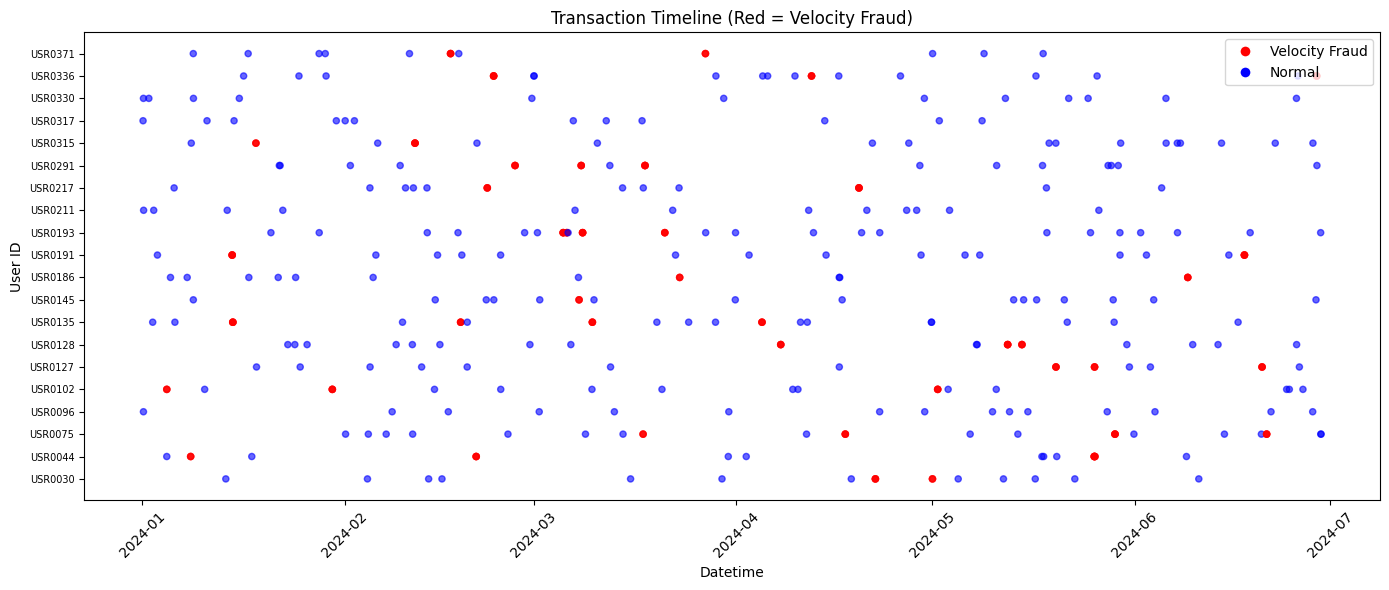

In [9]:
# 4. Timeline scatter plot (limited to 20 users)
from matplotlib.lines import Line2D

fig2, ax = plt.subplots(figsize=(14, 6))

fraud_users = df[df["velocity_fraud"]]["user_id"].unique()
if len(fraud_users) >= 20:
    selected_users = fraud_users[:20]
elif len(fraud_users) > 0:
    remaining = 20 - len(fraud_users)
    normal_users = df[~df["velocity_fraud"]]["user_id"].unique()
    selected_users = np.concatenate([fraud_users, normal_users[:remaining]])
else:
    selected_users = df["user_id"].unique()[:20]

plot_df = df[df["user_id"].isin(selected_users)].copy()
user_map = {u: i for i, u in enumerate(sorted(plot_df["user_id"].unique()))}
plot_df["user_num"] = plot_df["user_id"].map(user_map)

colors = plot_df["velocity_fraud"].map({True: "red", False: "blue"})
ax.scatter(
    plot_df["datetime"],
    plot_df["user_num"],
    c=colors,
    alpha=0.6,
    s=20,
)
ax.set_yticks(range(len(user_map)))
ax.set_yticklabels(sorted(plot_df["user_id"].unique()), fontsize=7)
ax.set_xlabel("Datetime")
ax.set_ylabel("User ID")
ax.set_title("Transaction Timeline (Red = Velocity Fraud)")
plt.xticks(rotation=45)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=8, label="Velocity Fraud"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=8, label="Normal"),
]
ax.legend(handles=legend_elements, loc="upper right")
fig2.tight_layout()
plt.show()
